In [2]:
from model import Model, Tokenizer, Tokenizer_linux

In [6]:
import pickle

wap_tokenizer = Tokenizer()
loaded = pickle.load(open("wap_tokenizer.pkl", "rb"))

wap_tokenizer.__dict__.update(loaded.__dict__)  

linux_tokenizer = Tokenizer_linux()
loaded = pickle.load(open("linux_tokenizer.pkl", "rb"))

linux_tokenizer.__dict__.update(loaded.__dict__)  

### Vocabulary Size Comparison

In [7]:
print("Vocabulary size of War and Peace tokenizer is: ", len(wap_tokenizer.idx_to_word))
print("Vocabulary size of Linux tokenizer is: ", len(linux_tokenizer.idx_to_word))

Vocabulary size of War and Peace tokenizer is:  20072
Vocabulary size of Linux tokenizer is:  44361


### Dataset Comparison

In [9]:
wap_corpus = open("warpeace_input.txt", "r").read()
wap_encoded_text = wap_tokenizer.encode(wap_corpus)

linux_corpus = open("linux_input.txt", "r").read()
linux_encoded_text = linux_tokenizer.encode(linux_corpus)

print("Number of tokens in warpeace: ", len(wap_encoded_text))
print("Number of tokens in linux: ", len(linux_encoded_text))

Number of tokens in warpeace:  654064
Number of tokens in linux:  1120671


### Most Frequent and Least Frequent words

In [19]:
from collections import Counter

# Count token frequencies
wap_counts = Counter(wap_encoded_text)
linux_counts = Counter(linux_encoded_text)

# Get most & least frequent tokens
wap_most_common = wap_counts.most_common(10)
wap_least_common = wap_counts.most_common()[:-11:-1]

linux_most_common = linux_counts.most_common(10)
linux_least_common = linux_counts.most_common()[:-11:-1]

# Print results
print("Top 10 most frequent tokens in War and Peace:")
for token, count in wap_most_common:
    print(f"Token {token}: {count}")

print("\n10 least frequent tokens in War and Peace:")
for token, count in wap_least_common:
    print(f"Token {token}: {count}")

print("\nTop 10 most frequent tokens in Linux corpus:")
for token, count in linux_most_common:
    print(f"Token {token}: {count}")

print("\n10 least frequent tokens in Linux corpus:")
for token, count in linux_least_common:
    print(f"Token {token}: {count}")


Top 10 most frequent tokens in War and Peace:
Token 1: 62014
Token 2: 34394
Token 3: 30590
Token 4: 22082
Token 5: 16636
Token 6: 14871
Token 7: 10464
Token 8: 9808
Token 9: 8743
Token 10: 7967

10 least frequent tokens in War and Peace:
Token 18717: 1
Token 15937: 1
Token 18530: 1
Token 16012: 1
Token 14408: 1
Token 17667: 1
Token 16189: 1
Token 18318: 1
Token 18867: 1
Token 18149: 1

Top 10 most frequent tokens in Linux corpus:
Token 1: 201920
Token 2: 77398
Token 3: 77362
Token 4: 77184
Token 5: 45848
Token 44359: 39343
Token 6: 35102
Token 7: 31591
Token 8: 27746
Token 9: 23157

10 least frequent tokens in Linux corpus:
Token 38323: 1
Token 31882: 1
Token 24413: 1
Token 22886: 1
Token 37062: 1
Token 41437: 1
Token 36903: 1
Token 29459: 1
Token 31673: 1
Token 40483: 1


In [20]:
from collections import Counter

# Count frequencies
wap_counts = Counter(wap_encoded_text)
linux_counts = Counter(linux_encoded_text)

# Get 10 most & least frequent tokens
wap_most_common = wap_counts.most_common(10)
wap_least_common = wap_counts.most_common()[:-11:-1]

linux_most_common = linux_counts.most_common(10)
linux_least_common = linux_counts.most_common()[:-11:-1]


def print_token_stats(title, token_counts, tokenizer):
    print(f"\n{title}")
    print("-" * len(title))
    for token_id, count in token_counts:
        try:
            token_str = tokenizer.decode([token_id])
        except Exception:
            token_str = "<decode_error>"
        print(f"Token ID: {token_id:<6} | Count: {count:<6} | Token: {repr(token_str)}")


# War and Peace corpus
print_token_stats("Top 10 most frequent tokens in War and Peace", wap_most_common, wap_tokenizer)
print_token_stats("10 least frequent tokens in War and Peace", wap_least_common, wap_tokenizer)

# Linux corpus
print_token_stats("Top 10 most frequent tokens in Linux corpus", linux_most_common, linux_tokenizer)
print_token_stats("10 least frequent tokens in Linux corpus", linux_least_common, linux_tokenizer)



Top 10 most frequent tokens in War and Peace
--------------------------------------------
Token ID: 1      | Count: 62014  | Token: '\n'
Token ID: 2      | Count: 34394  | Token: 'the'
Token ID: 3      | Count: 30590  | Token: '.'
Token ID: 4      | Count: 22082  | Token: 'and'
Token ID: 5      | Count: 16636  | Token: 'to'
Token ID: 6      | Count: 14871  | Token: 'of'
Token ID: 7      | Count: 10464  | Token: 'a'
Token ID: 8      | Count: 9808   | Token: 'he'
Token ID: 9      | Count: 8743   | Token: 'in'
Token ID: 10     | Count: 7967   | Token: 'his'

10 least frequent tokens in War and Peace
-----------------------------------------
Token ID: 18717  | Count: 1      | Token: 'unreal'
Token ID: 15937  | Count: 1      | Token: 'earths'
Token ID: 18530  | Count: 1      | Token: 'personalityfree'
Token ID: 16012  | Count: 1      | Token: 'immovability'
Token ID: 14408  | Count: 1      | Token: 'strengthens'
Token ID: 17667  | Count: 1      | Token: 'uninvited'
Token ID: 16189  | Count

### Loss curve Comparison

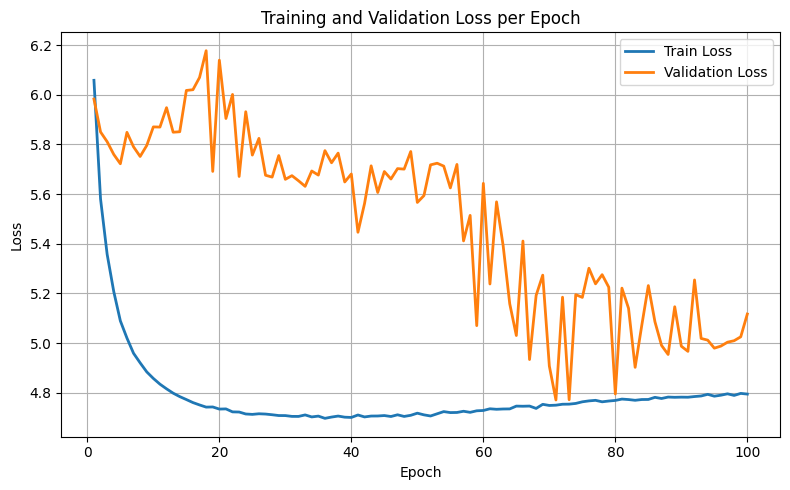

In [21]:
import numpy as np
train_loss_per_epoch = np.load("losses/wap_train.npy")
val_loss_per_epoch = np.load("losses/wap_val.npy")
import matplotlib.pyplot as plt

epochs = range(1, len(train_loss_per_epoch) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss_per_epoch, label='Train Loss', linewidth=2)
plt.plot(epochs, val_loss_per_epoch, label='Validation Loss', linewidth=2)

plt.title("Training and Validation Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


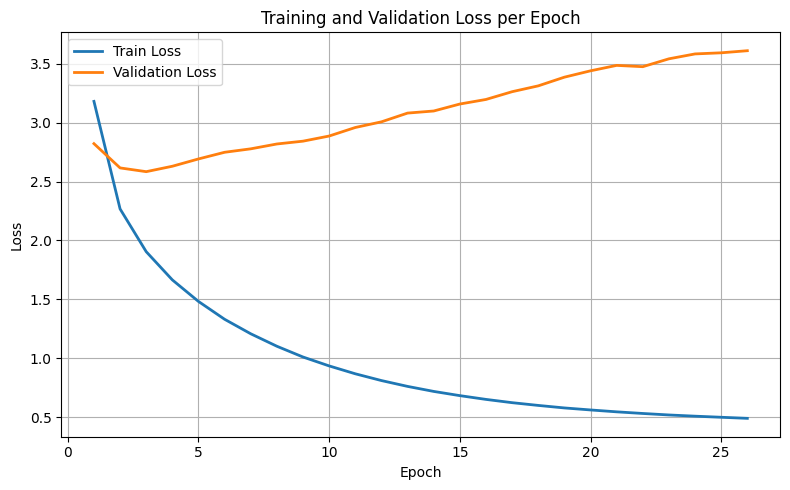

In [23]:
import numpy as np
train_loss_per_epoch = np.load("losses/linux_train.npy")
val_loss_per_epoch = np.load("losses/linux_val.npy")
import matplotlib.pyplot as plt

epochs = range(1, len(train_loss_per_epoch) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss_per_epoch, label='Train Loss', linewidth=2)
plt.plot(epochs, val_loss_per_epoch, label='Validation Loss', linewidth=2)

plt.title("Training and Validation Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
